In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("./data/IMDB Dataset.csv")

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.sample(5)

,review,sentiment
22162,New York I Love You is full of love and power....,positive
26039,An annoying and talentless American documentar...,negative
48029,House of games has a strong story where obsess...,positive
39686,Few movies have dashed expectations and upset ...,negative
48336,This is a great example of what happened at Co...,negative


In [5]:
df_pos = df[df['sentiment']=='positive'][:5000]
df_neg = df[df['sentiment']=='negative'][:5000]

df_reviews = pd.concat([df_pos, df_neg ])

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
train,test = train_test_split(df_reviews,test_size =0.33,random_state=42)

In [8]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [9]:
train_y.value_counts()

sentiment
negative    3378
positive    3322
Name: count, dtype: int64

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)
test_x_vector = tfidf.transform(test_x)

In [12]:
train_x.shape

(6700,)

In [13]:
train_x_vector.shape

(6700, 44107)

In [14]:
type(train_x_vector)

scipy.sparse._csr.csr_matrix

In [15]:
primera_resenia = pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                  index=train_x.index,
                                  columns=tfidf.get_feature_names_out()).iloc[0]

In [16]:
primera_resenia

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [17]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [18]:
primera_resenia[primera_resenia != 0]

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [19]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [20]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


In [22]:
print(svc.score(test_x_vector, test_y))

0.8706060606060606


In [23]:
from sklearn.metrics import f1_score

f1_score(test_y,svc.predict(test_x_vector),
          labels = ['positive','negative'],average=None)

array([0.87400413, 0.86701962])

In [24]:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                            svc.predict(test_x_vector),
                            labels = ['positive','negative']))

              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



In [25]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(test_y,
                           svc.predict(test_x_vector),
                           labels = ['positive', 'negative'])
conf_mat

array([[1481,  197],
       [ 230, 1392]])

## Comparación con otros modelos de clasificación

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import accuracy_score, f1_score

In [27]:
resultados_modelos = []

pred_svc = svc.predict(test_x_vector)

resultados_modelos.append({
    "Modelo": "SVC lineal",
    "Accuracy": accuracy_score(test_y, pred_svc),
    "F1 macro": f1_score(test_y, pred_svc, average="macro")
})

resultados_modelos

[{'Modelo': 'SVC lineal',
  'Accuracy': 0.8706060606060606,
  'F1 macro': 0.8705118755340776}]

In [28]:
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(train_x_vector, train_y)

pred_logistico = modelo_logistico.predict(test_x_vector)

resultados_modelos.append({
    "Modelo": "Regresión logística",
    "Accuracy": accuracy_score(test_y, pred_logistico),
    "F1 macro": f1_score(test_y, pred_logistico, average="macro")
})

print(
    "Accuracy Regresión Logística:",
    accuracy_score(test_y, pred_logistico)
)

Accuracy Regresión Logística: 0.8718181818181818


In [29]:
svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

train_x_reducido = svd.fit_transform(train_x_vector)
test_x_reducido = svd.transform(test_x_vector)

print("Entrenamiento:", train_x_reducido.shape)
print("Prueba:", test_x_reducido.shape)

Entrenamiento: (6700, 300)
Prueba: (3300, 300)


In [30]:
modelo_gaussian = GaussianNB()

modelo_gaussian.fit(
    train_x_reducido,
    train_y
)

pred_gaussian = modelo_gaussian.predict(
    test_x_reducido
)

resultados_modelos.append({
    "Modelo": "GaussianNB",
    "Accuracy": accuracy_score(test_y, pred_gaussian),
    "F1 macro": f1_score(test_y, pred_gaussian, average="macro")
})

print(
    "Accuracy GaussianNB:",
    accuracy_score(test_y, pred_gaussian)
)

Accuracy GaussianNB: 0.8103030303030303


In [31]:
modelo_arbol = DecisionTreeClassifier(
    random_state=42
)

modelo_arbol.fit(
    train_x_vector,
    train_y
)

pred_arbol = modelo_arbol.predict(
    test_x_vector
)

resultados_modelos.append({
    "Modelo": "Árbol de decisión",
    "Accuracy": accuracy_score(test_y, pred_arbol),
    "F1 macro": f1_score(test_y, pred_arbol, average="macro")
})

print(
    "Accuracy Árbol de Decisión:",
    accuracy_score(test_y, pred_arbol)
)

Accuracy Árbol de Decisión: 0.7163636363636363


In [32]:
comparacion_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

comparacion_modelos["Accuracy"] = (
    comparacion_modelos["Accuracy"] * 100
).round(2)

comparacion_modelos["F1 macro"] = (
    comparacion_modelos["F1 macro"] * 100
).round(2)

comparacion_modelos

,Modelo,Accuracy,F1 macro
0,Regresión logística,87.18,87.17
1,SVC lineal,87.06,87.05
2,GaussianNB,81.03,81.01
3,Árbol de decisión,71.64,71.64


In [33]:
fila_tfidf = train_x_vector[0]

indices_no_cero = fila_tfidf.nonzero()[1]

primera_resenia = pd.Series(
    fila_tfidf.data,
    index=tfidf.get_feature_names_out()[indices_no_cero]
).sort_values(ascending=False)

primera_resenia

13              0.458490
movie           0.276309
pg              0.260154
disgusting      0.237945
references      0.226901
rated           0.206643
happened        0.176853
pedophilia      0.172712
joked           0.168137
deplorable      0.168137
revolting       0.151971
year            0.149022
beware          0.143046
allowing        0.128240
17              0.128240
mature          0.126021
br              0.124945
old             0.123513
safe            0.119732
watching        0.118602
humorous        0.116516
hopes           0.114028
teen            0.109104
shouldn         0.108203
touch           0.103496
expectations    0.103149
sexual          0.098677
sister          0.095008
rent            0.093234
bunch           0.093128
actual          0.091601
age             0.088765
including       0.087603
wouldn          0.087362
humor           0.084465
entertaining    0.081088
went            0.080113
stupid          0.079022
small           0.078916
truly           0.078241


## Evaluación del mejor modelo

La regresión logística obtuvo la mayor precisión y el mayor F1 macro, por lo que fue seleccionada como el mejor modelo para clasificar las reseñas.

In [34]:
print(
    classification_report(
        test_y,
        pred_logistico,
        labels=["positive", "negative"]
    )
)

              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



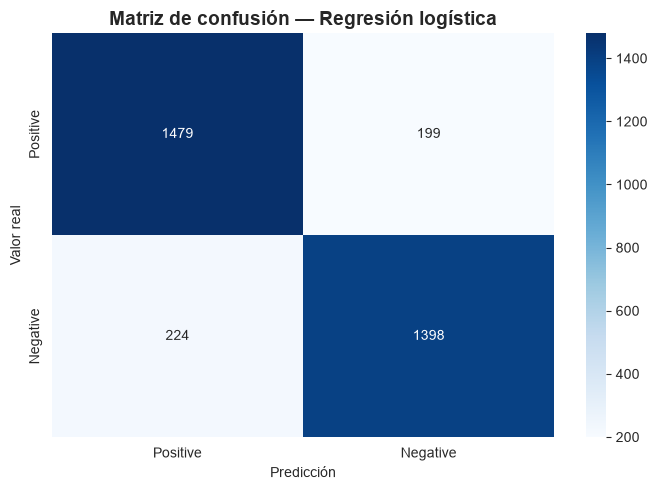

In [35]:
confusion_logistica = confusion_matrix(
    test_y,
    pred_logistico,
    labels=["positive", "negative"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_logistica,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"]
)

plt.title(
    "Matriz de confusión — Regresión logística",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## Conclusión

Se entrenaron y evaluaron cuatro modelos de clasificación para identificar si una reseña cinematográfica es positiva o negativa.

La regresión logística obtuvo el mejor resultado, con una precisión de **87.18 %** y un F1 macro de **87.17 %**. El modelo SVC lineal presentó un rendimiento prácticamente equivalente, con una precisión de **87.06 %**.

GaussianNB alcanzó una precisión de **81.03 %** después de aplicar reducción de dimensionalidad mediante TruncatedSVD. Aunque su resultado fue aceptable, quedó por debajo de los modelos lineales.

El árbol de decisión obtuvo el rendimiento más bajo, con una precisión de **71.64 %**. Esto indica que un árbol individual no se adapta tan bien a la elevada dimensionalidad generada por TF-IDF.

Por su equilibrio entre precisión, velocidad, simplicidad e interpretabilidad, se selecciona la regresión logística como el modelo más conveniente para este proyecto de análisis de sentimientos.m